
**Dataset:** 284,807 real credit card transactions, September 2013  
**Target:** Class 0 = Legitimate, Class 1 = Fraud

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Load the datset 
df = pd.read_csv('creditcard.csv')
print(df.head())
print(df.info())
print(df.shape)


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

#Class imbalance analysis
The **class** column is what we are predicting
**We expect very few fraud cases - this is called class imbalance,
and this is the central challenge of this project



Legitimate transactions: 284315
Fraudulent transactions: 492
Percentage of fraud cases: 0.17%


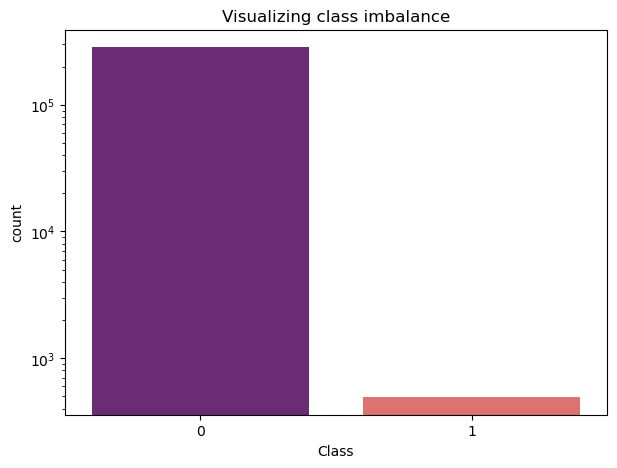

In [12]:
#Calculate the percentages of fraud cases
counts = df['Class'].value_counts()
percent_fraud = (counts[1] / (counts[0] + counts[1])) * 100
print(f"Legitimate transactions: {counts[0]}")
print(f"Fraudulent transactions: {counts[1]}")
print(f"Percentage of fraud cases: {percent_fraud:.2f}%")
#Plotting the imbalance
plt.figure(figsize=(7,5))
sns.countplot(x='Class', data=df, hue='Class', palette='magma', legend=False)
plt.title('Visualizing class imbalance')
plt.yscale('log') #using a log scale to make tiny fraud bar visible
plt.show()


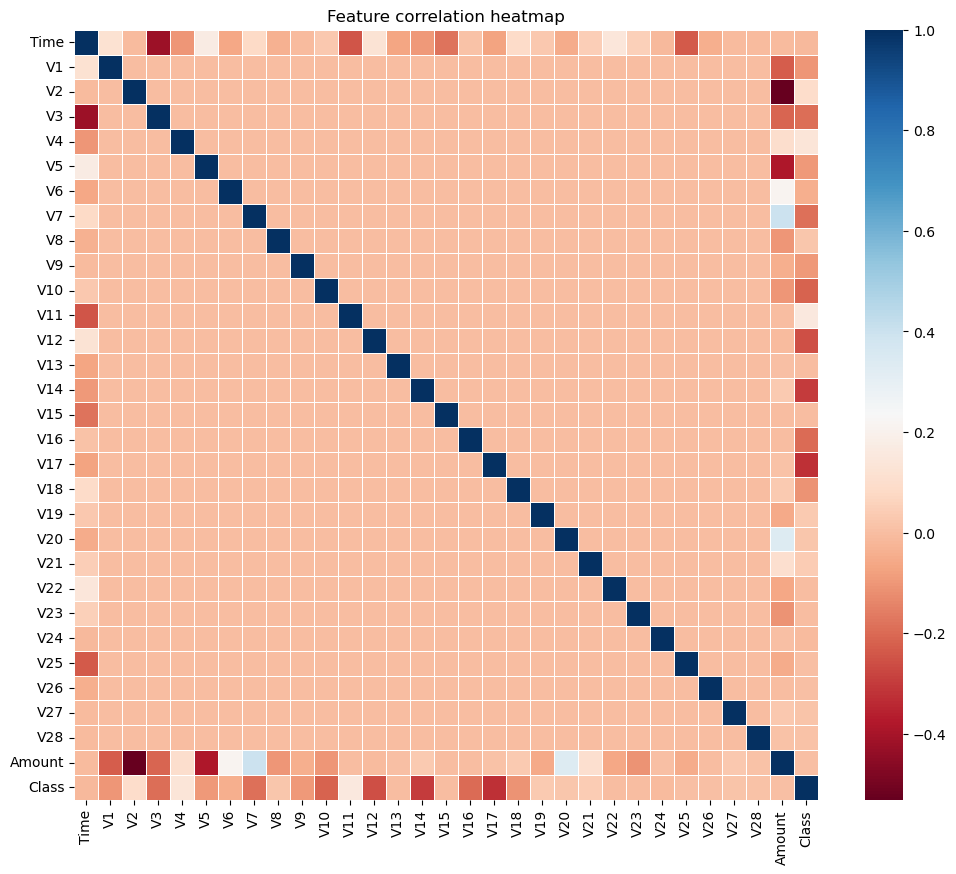

In [9]:
#Corelation heatmap
plt.figure(figsize=(12,10))
#calculate the corelation matrix
corr = df.corr()
#Plot the heatmap
sns.heatmap(corr, cmap='RdBu', annot=False, linewidths=0.5)
plt.title('Feature correlation heatmap')
plt.show()

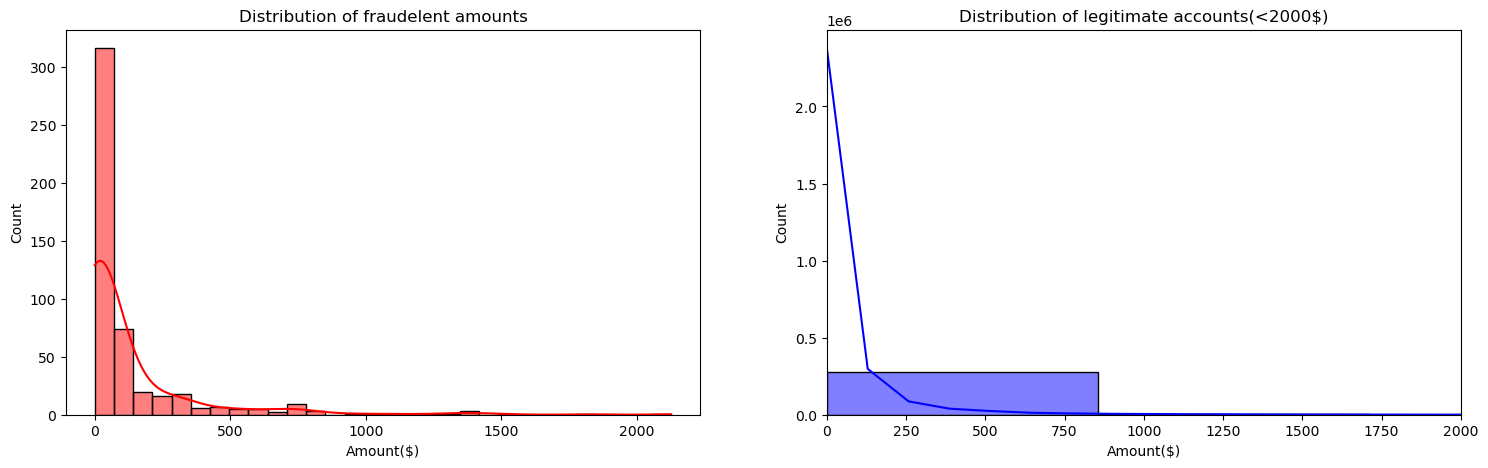

In [10]:
#Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18,5))
#Plot for fraudelent transactions
sns.histplot(df[df['Class'] == 1] ['Amount'], bins=30, ax=ax1, kde=True, color='red')
ax1.set_title('Distribution of fraudelent amounts')
ax1.set_xlabel('Amount($)')
#Plot for legitimate transactions
sns.histplot(df[df['Class'] == 0]['Amount'], bins=30, ax=ax2, kde=True, color='blue')
ax2.set_xlim([0,2000])
ax2.set_title('Distribution of legitimate accounts(<2000$)')
ax2.set_xlabel('Amount($)')
plt.show()